# Baseline vs Endline Comparison EDA

This notebook links baseline and endline survey datasets by client ID and performs comparative analysis:

- Join coverage diagnostics
- Distribution shifts across key outcomes
- Client-level delta analysis (paired records)
- Segment-level change analysis by location, sector, and demographics
- Data quality caveats for interpretation

In [5]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 180)
np.random.seed(42)

In [6]:
def find_ml_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Anomynized data').exists() and (p / 'notebooks').exists():
            return p
        if (p / 'ml' / 'Anomynized data').exists():
            return p / 'ml'
    raise FileNotFoundError('Could not locate ml root containing Anomynized data directory.')

def load_csv_with_fallback(csv_path: Path) -> pd.DataFrame:
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    # Last resort: replace undecodable bytes so EDA can continue.
    return pd.read_csv(csv_path, encoding='utf-8', encoding_errors='replace')

ml_root = find_ml_root()
data_dir = ml_root / 'Anomynized data' / 'Anomynized data' / 'Anomynized data'
baseline_path = data_dir / 'baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv'
endline_path = data_dir / 'endline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv'

base = load_csv_with_fallback(baseline_path)
end = load_csv_with_fallback(endline_path)

print('Baseline shape:', base.shape)
print('Endline shape :', end.shape)

Baseline shape: (8976, 21)
Endline shape : (8976, 26)


In [7]:
for df in [base, end]:
    if 'client_id' in df.columns:
        df['client_id'] = df['client_id'].astype(str).str.strip()
    if 'survey_date' in df.columns:
        df['survey_date'] = pd.to_datetime(df['survey_date'], errors='coerce', dayfirst=True)

num_cols = ['age', 'number_of_people_reponsible', 'monthly_customer', 'job_created', 'revenue', 'hh_expense']
for c in num_cols:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors='coerce')
    if c in end.columns:
        end[c] = pd.to_numeric(end[c], errors='coerce')

for c in ['nps_detractor', 'nps_passive', 'nps_promoter', 'satisfied_yes', 'satisfied_no']:
    if c in end.columns:
        end[c] = pd.to_numeric(end[c], errors='coerce')

print('Baseline unique client_id:', base['client_id'].nunique() if 'client_id' in base.columns else 'N/A')
print('Endline unique client_id :', end['client_id'].nunique() if 'client_id' in end.columns else 'N/A')

Baseline unique client_id: 8976
Endline unique client_id : 8976


In [8]:
join_diag = base[['client_id']].merge(end[['client_id']], on='client_id', how='outer', indicator=True)
coverage = join_diag['_merge'].value_counts().rename('count').to_frame()
coverage['pct'] = (coverage['count'] / len(join_diag) * 100).round(2)
display(coverage)

matched = join_diag.query("_merge == 'both'")['client_id']
base_matched = base[base['client_id'].isin(matched)].copy()
end_matched = end[end['client_id'].isin(matched)].copy()

paired = base_matched.merge(end_matched, on='client_id', suffixes=('_base', '_end'), how='inner')
print('Matched clients:', len(matched))
print('Paired rows   :', paired.shape)

,count,pct
_merge,,
both,8976,100.0
left_only,0,0.0
right_only,0,0.0


Matched clients: 8976
Paired rows   : (8976, 46)


,metric,baseline_mean,endline_mean,delta_mean,delta_median,improved_pct
0,revenue,1023.705,1491.962,454.975,166.929,67.291
1,hh_expense,138.898,197.261,49.053,39.557,24.610
2,job_created,1.721,2.006,0.241,0.000,30.983
3,monthly_customer,784.544,2032.700,1253.341,53.000,55.827


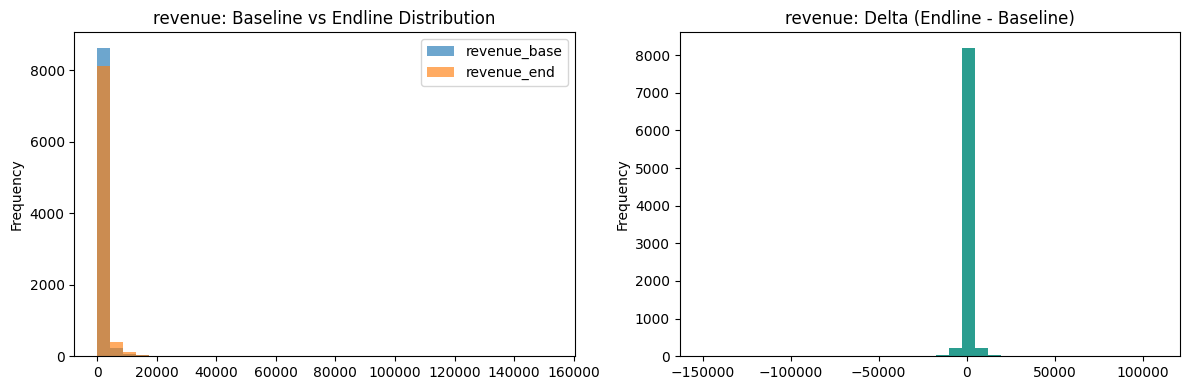

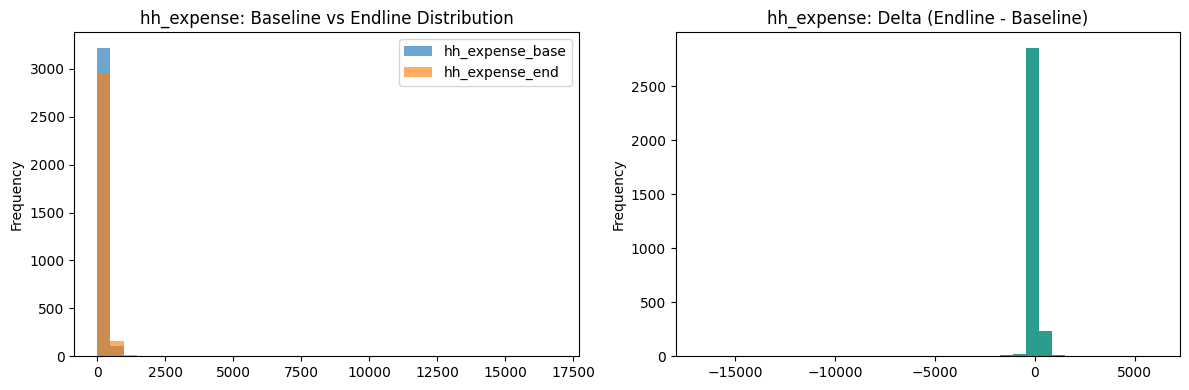

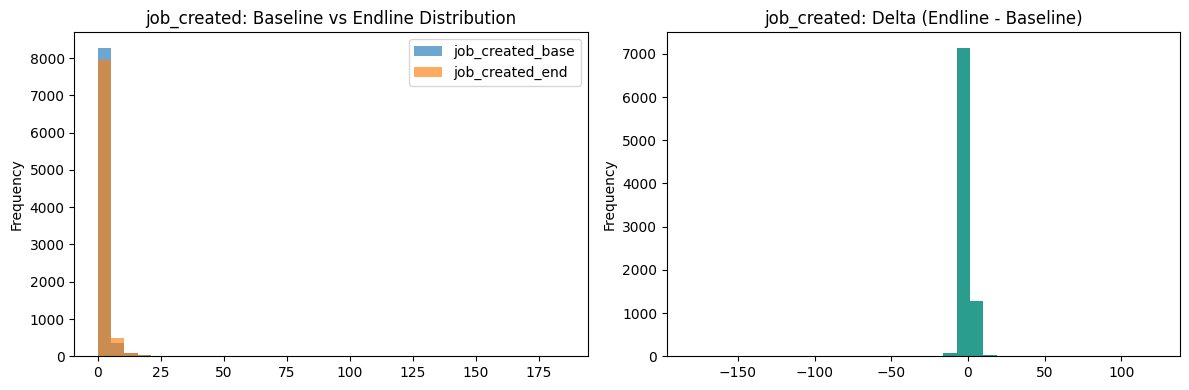

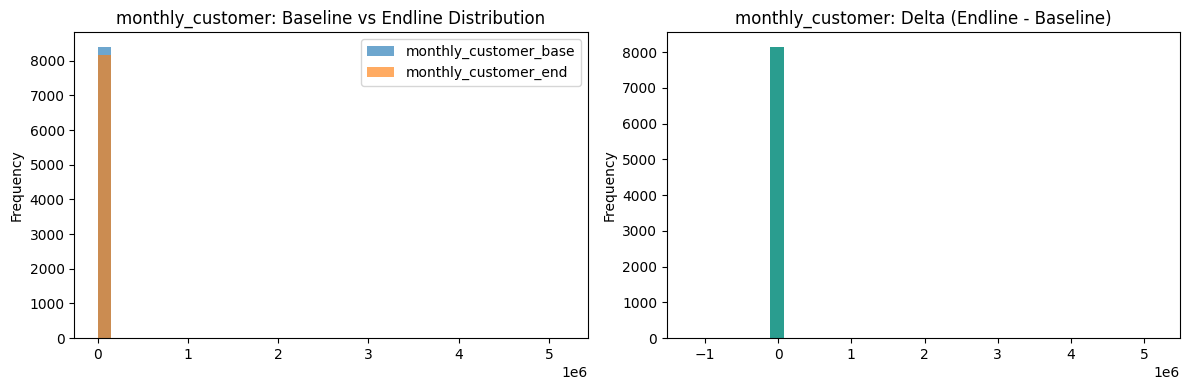

In [9]:
outcome_cols = ['revenue', 'hh_expense', 'job_created', 'monthly_customer']
summary_rows = []
for c in outcome_cols:
    b = f'{c}_base'
    e = f'{c}_end'
    if b in paired.columns and e in paired.columns:
        delta = paired[e] - paired[b]
        summary_rows.append({
            'metric': c,
            'baseline_mean': paired[b].mean(),
            'endline_mean': paired[e].mean(),
            'delta_mean': delta.mean(),
            'delta_median': delta.median(),
            'improved_pct': (delta > 0).mean() * 100
        })

delta_summary = pd.DataFrame(summary_rows).round(3)
display(delta_summary)

for c in outcome_cols:
    b = f'{c}_base'
    e = f'{c}_end'
    if b in paired.columns and e in paired.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        paired[[b, e]].plot(kind='hist', bins=35, alpha=0.65, ax=axes[0])
        axes[0].set_title(f'{c}: Baseline vs Endline Distribution')
        (paired[e] - paired[b]).dropna().plot(kind='hist', bins=35, ax=axes[1], color='#2a9d8f')
        axes[1].set_title(f'{c}: Delta (Endline - Baseline)')
        plt.tight_layout()
        plt.show()

In [10]:
segment_candidates = ['business_location_base', 'business_sector_base', 'gender_base', 'education_level_base', 'strata_base']
segment_cols = [c for c in segment_candidates if c in paired.columns]

for seg in segment_cols:
    print(f'Segment delta summary: {seg}')
    grp = paired.groupby(seg).agg(
        n=('client_id', 'count'),
        revenue_delta_mean=('revenue_end', lambda x: (x - paired.loc[x.index, 'revenue_base']).mean()) if {'revenue_end','revenue_base'}.issubset(paired.columns) else ('client_id', 'count'),
        jobs_delta_mean=('job_created_end', lambda x: (x - paired.loc[x.index, 'job_created_base']).mean()) if {'job_created_end','job_created_base'}.issubset(paired.columns) else ('client_id', 'count')
    ).sort_values('n', ascending=False)
    display(grp.head(20))

if {'have_bank_account_base', 'has_access_to_finance_in_past6months_base', 'have_bank_account_end', 'has_access_to_finance_in_past6months_end'}.issubset(paired.columns):
    trans = pd.crosstab(
        paired['have_bank_account_base'].astype(str) + ' | ' + paired['has_access_to_finance_in_past6months_base'].astype(str),
        paired['have_bank_account_end'].astype(str) + ' | ' + paired['has_access_to_finance_in_past6months_end'].astype(str),
        normalize='index'
    )
    display((trans * 100).round(2))

Segment delta summary: business_location_base


,n,revenue_delta_mean,jobs_delta_mean
business_location_base,,,
Musanze,670,-32.717223,-0.320182
Rusizi,644,447.074090,0.579439
Huye,616,-24.533114,0.467446
Kayonza,475,32.753614,0.307036
Kebribeyah Town,366,833.337086,0.095890
Gatsibo,354,99.952231,-0.002882
Kirehe,333,330.118082,0.290429
Karongi,331,646.530551,-0.209375
Nyamagabe,328,491.676030,0.082803


Segment delta summary: business_sector_base


,n,revenue_delta_mean,jobs_delta_mean
business_sector_base,,,
Retail Sales and Grocery,2309,378.762447,0.299907
Fashion and Apparel,1201,191.694746,0.257391
Food and Beverage Retail,809,353.689006,0.360656
"Agribusiness,Processing,and Farming",782,-265.080948,-1.058278
"Tech,Digital Services,Ecommerce",540,-364.443094,-0.030651
Retail Sales & Grocery,330,545.341912,0.851515
Fashion And Apparel,268,1165.661204,0.712687
Retail Shop,241,529.194350,-0.012448
Retail Sales And Grocery,197,1077.844947,0.841026


Segment delta summary: gender_base


...

Segment delta summary: education_level_base


,n,revenue_delta_mean,jobs_delta_mean
education_level_base,,,
Attended High School,1981,218.939960,0.208421
Finished High School/Graduate,1210,148.647024,0.039417
Finished Primary School,1124,256.605562,0.162684
Attended Primary School,924,32.639338,-0.006719
No Formal Education,665,865.377480,0.166410
Attended Primary,403,671.296066,0.614428
Finished Primary,326,944.632919,1.190184
Diploma,270,941.130423,0.099617
University Degree and Higher,211,-896.042800,-0.210000


Segment delta summary: strata_base


,n,revenue_delta_mean,jobs_delta_mean
strata_base,,,
Host,6008,356.970693,0.171867
Refugee,2968,656.741154,0.389505


col_0,No | No,No | Yes,No | nan,No | no,No | yes,Yes | No,Yes | Yes,Yes | nan,Yes | no,Yes | yes,nan | No,nan | nan
row_0,,,,,,,,,,,,
No | No,71.06,11.88,0.11,4.21,3.89,5.29,3.56,0.00,0.00,0.00,0.00,0.00
No | Yes,24.24,57.07,0.00,0.00,1.01,10.10,6.57,0.00,0.00,0.00,0.00,1.01
No | nan,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Yes | No,3.30,1.98,0.00,0.00,0.00,48.98,20.44,0.07,17.53,7.71,0.00,0.00
Yes | Yes,2.41,2.09,0.00,0.00,0.00,37.88,49.60,0.00,5.94,2.09,0.00,0.00
Yes | nan,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00
nan | No,0.00,0.00,0.00,0.00,0.00,33.33,33.33,0.00,0.00,0.00,33.33,0.00
nan | nan,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.00,0.00,0.00,0.02,99.94


In [11]:
quality = {}
quality['baseline_duplicates'] = int(base.duplicated().sum())
quality['endline_duplicates'] = int(end.duplicated().sum())
quality['paired_rows'] = int(len(paired))
quality['baseline_only_clients'] = int((join_diag['_merge'] == 'left_only').sum())
quality['endline_only_clients'] = int((join_diag['_merge'] == 'right_only').sum())

if {'nps_detractor', 'nps_passive', 'nps_promoter'}.issubset(end.columns):
    nps_sum = end[['nps_detractor', 'nps_passive', 'nps_promoter']].sum(axis=1)
    quality['endline_nps_not_one_hot'] = int((nps_sum != 1).sum())

display(pd.Series(quality, name='count').to_frame())

print('Interpretation Caveats:')
print('- Comparison metrics depend on matched clients and may not represent full baseline/endline cohorts.')
print('- Missing values and categorical recoding differences can bias segment-level deltas.')
print('- Outlier-sensitive metrics (revenue/expense) should be reviewed with robust statistics.')
print('- Causal claims require intervention assignment context and stronger evaluation design.')

,count
baseline_duplicates,0
endline_duplicates,0
paired_rows,8976
baseline_only_clients,0
endline_only_clients,0
endline_nps_not_one_hot,38


Interpretation Caveats:
- Comparison metrics depend on matched clients and may not represent full baseline/endline cohorts.
- Missing values and categorical recoding differences can bias segment-level deltas.
- Outlier-sensitive metrics (revenue/expense) should be reviewed with robust statistics.
- Causal claims require intervention assignment context and stronger evaluation design.
